디바이스: cuda
증강 데이터 로드: 700개
test 데이터 로드: 157개

3분류 변환 데이터 저장 완료
→ train_3class_full.csv
→ test_3class.csv

=== 병합 후 클래스 분포 ===
train:
label
0    160
1    131
2    409
Name: count, dtype: int64
test:
label
0    45
1    26
2    86
Name: count, dtype: int64

train: 560개 / val: 140개
3분류 분할 데이터 저장 완료
→ train_3class.csv
→ val_3class.csv

=== Class Weights ===
클래스 0: 1.4583  샘플 수: 128개
클래스 1: 1.7778  샘플 수: 105개
클래스 2: 0.5708  샘플 수: 327개


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: beomi/kcelectra-base-v2022
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the che


=== 학습 시작 ===
[Epoch 1/5] loss: 1.0146 | train_acc: 0.5911 | val_acc: 0.7643 | val_kappa: 0.7442


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

best 모델 저장 완료 → /content/kcelectra_churn_3class_best

최고 성능 Epoch: 5
Best Validation Kappa: 0.8736


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

최종 모델 저장 완료 → /content/kcelectra_churn_3class_final

=== 테스트 평가 ===


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Test Accuracy  : 86.0%
Quadratic Kappa: 0.8958

=== Classification Report ===
              precision    recall  f1-score   support

      0-이탈없음     0.9767    0.9333    0.9545        45
      1-약한불만     0.6087    0.5385    0.5714        26
      2-이탈위험     0.8681    0.9186    0.8927        86

    accuracy                         0.8599       157
   macro avg     0.8179    0.7968    0.8062       157
weighted avg     0.8563    0.8599    0.8572       157



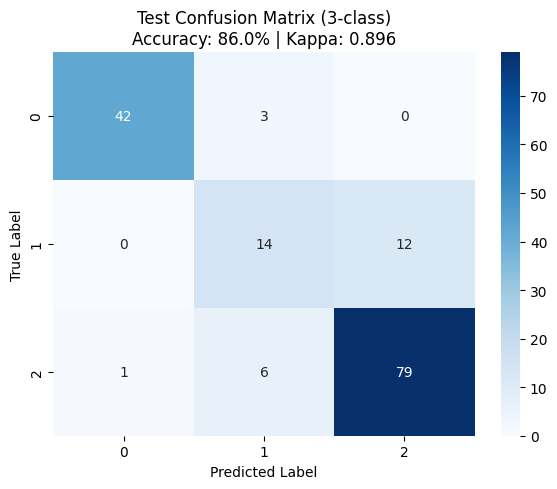

혼동행렬 이미지 저장 완료 → confusion_matrix_3class_test.png

=== 클래스별 Recall (Test) ===
클래스 0: 93.3%  ██████████████████
클래스 1: 53.8%  ██████████
클래스 2: 91.9%  ██████████████████

테스트 예측 결과 저장 완료 → test_result_3class.csv

압축 파일 저장 완료
→ kcelectra_churn_3class_best.zip
→ kcelectra_churn_3class_final.zip

=== 전체 저장 파일 목록 ===
train_3class_full.csv
train_3class.csv
val_3class.csv
test_3class.csv
test_result_3class.csv
confusion_matrix_3class_test.png
kcelectra_churn_3class_best.zip
kcelectra_churn_3class_final.zip


In [3]:
# ============================================================
# KcELECTRA 3분류 파이프라인
# 0=이탈없음 / 1=약한불만 / 2=이탈위험(기존 2+3)
# 데이터 저장 + 모델 저장 포함
# ============================================================

!pip install transformers scikit-learn seaborn -q

import os
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn import CrossEntropyLoss
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    cohen_kappa_score, accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_NAME = "beomi/kcelectra-base-v2022"
MODEL_SAVE = "/content/kcelectra_churn_3class_best"
FINAL_MODEL_SAVE = "/content/kcelectra_churn_3class_final"

MAX_LEN = 128
EPOCHS = 5
N_CLASSES = 3
LABEL_NAMES = ["0-이탈없음", "1-약한불만", "2-이탈위험"]

print(f"디바이스: {DEVICE}")

# ── 1. 데이터 로드 ──────────────────────────────

if os.path.exists("train_augmented.csv"):
    train_raw = pd.read_csv("train_augmented.csv")
    print(f"증강 데이터 로드: {len(train_raw)}개")
else:
    train_raw = pd.read_csv("train.csv")
    print(f"원본 train 데이터 로드: {len(train_raw)}개")

test_raw = pd.read_csv("test.csv")
print(f"test 데이터 로드: {len(test_raw)}개")

# ── 2. 라벨 병합: 기존 3 → 2 ──────────────────────────────

def merge_labels(df):
    df = df.copy()
    df["label"] = df["label"].replace({3: 2})
    return df

train_df_full = merge_labels(train_raw)
test_df = merge_labels(test_raw)

# 3분류 전체 데이터 저장
train_df_full.to_csv("train_3class_full.csv", index=False, encoding="utf-8-sig")
test_df.to_csv("test_3class.csv", index=False, encoding="utf-8-sig")

print("\n3분류 변환 데이터 저장 완료")
print("→ train_3class_full.csv")
print("→ test_3class.csv")

print("\n=== 병합 후 클래스 분포 ===")
print("train:")
print(train_df_full["label"].value_counts().sort_index())
print("test:")
print(test_df["label"].value_counts().sort_index())

# ── 3. train / validation 분할 ──────────────────────────────

train_df, val_df = train_test_split(
    train_df_full,
    test_size=0.2,
    random_state=42,
    stratify=train_df_full["label"]
)

train_df.to_csv("train_3class.csv", index=False, encoding="utf-8-sig")
val_df.to_csv("val_3class.csv", index=False, encoding="utf-8-sig")

print(f"\ntrain: {len(train_df)}개 / val: {len(val_df)}개")
print("3분류 분할 데이터 저장 완료")
print("→ train_3class.csv")
print("→ val_3class.csv")

# ── 4. Class Weight 계산 ──────────────────────────────

label_counts = train_df["label"].value_counts().sort_index()
total = len(train_df)

class_weights = torch.tensor([
    total / (N_CLASSES * label_counts[i]) for i in range(N_CLASSES)
], dtype=torch.float).to(DEVICE)

print("\n=== Class Weights ===")
for i, w in enumerate(class_weights):
    print(f"클래스 {i}: {w:.4f}  샘플 수: {label_counts[i]}개")

# ── 5. Dataset 정의 ──────────────────────────────

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ReviewDataset(Dataset):
    def __init__(self, dataframe):
        self.texts = dataframe["clean_review"].fillna("").tolist()
        self.labels = dataframe["label"].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {
            "input_ids": enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "label": torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_loader = DataLoader(ReviewDataset(train_df), batch_size=16, shuffle=True)
val_loader = DataLoader(ReviewDataset(val_df), batch_size=16, shuffle=False)
test_loader = DataLoader(ReviewDataset(test_df), batch_size=16, shuffle=False)

# ── 6. 모델 준비 ──────────────────────────────

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=N_CLASSES
).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
loss_fn = CrossEntropyLoss(weight=class_weights)

# ── 7. 학습 / 평가 함수 ──────────────────────────────

def train_epoch(model, loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in loader:
        ids = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        optimizer.zero_grad()

        logits = model(input_ids=ids, attention_mask=mask).logits
        loss = loss_fn(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (logits.argmax(-1) == labels).sum().item()
        total += len(labels)

    return total_loss / len(loader), correct / total


def evaluate(model, loader):
    model.eval()
    preds, trues, probs = [], [], []

    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            labels = batch["label"].to(DEVICE)

            logits = model(input_ids=ids, attention_mask=mask).logits
            prob = torch.softmax(logits, dim=-1)

            preds.extend(logits.argmax(-1).cpu().numpy())
            trues.extend(labels.cpu().numpy())
            probs.extend(prob.cpu().numpy())

    return np.array(preds), np.array(trues), np.array(probs)

# ── 8. 학습 실행 + best 모델 저장 ──────────────────────────────

print("\n=== 학습 시작 ===")

best_kappa = -1
best_epoch = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader)

    val_preds, val_labels, _ = evaluate(model, val_loader)
    val_acc = accuracy_score(val_labels, val_preds)
    kappa = cohen_kappa_score(val_labels, val_preds, weights="quadratic")

    print(
        f"[Epoch {epoch}/{EPOCHS}] "
        f"loss: {tr_loss:.4f} | "
        f"train_acc: {tr_acc:.4f} | "
        f"val_acc: {val_acc:.4f} | "
        f"val_kappa: {kappa:.4f}"
    )

    if kappa > best_kappa:
        best_kappa = kappa
        best_epoch = epoch

        model.save_pretrained(MODEL_SAVE)
        tokenizer.save_pretrained(MODEL_SAVE)

        print(f"best 모델 저장 완료 → {MODEL_SAVE}")

print(f"\n최고 성능 Epoch: {best_epoch}")
print(f"Best Validation Kappa: {best_kappa:.4f}")

# 마지막 epoch 모델도 따로 저장
model.save_pretrained(FINAL_MODEL_SAVE)
tokenizer.save_pretrained(FINAL_MODEL_SAVE)

print(f"최종 모델 저장 완료 → {FINAL_MODEL_SAVE}")

# ── 9. best 모델 불러와서 테스트 평가 ──────────────────────────────

print("\n=== 테스트 평가 ===")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_SAVE,
    num_labels=N_CLASSES
).to(DEVICE)

test_preds, test_labels, test_probs = evaluate(model, test_loader)

acc = accuracy_score(test_labels, test_preds)
kappa = cohen_kappa_score(test_labels, test_preds, weights="quadratic")

print("\n" + "=" * 40)
print(f"Test Accuracy  : {acc * 100:.1f}%")
print(f"Quadratic Kappa: {kappa:.4f}")
print("=" * 40)

print("\n=== Classification Report ===")
print(
    classification_report(
        test_labels,
        test_preds,
        target_names=LABEL_NAMES,
        digits=4
    )
)

# ── 10. 혼동행렬 저장 ──────────────────────────────

cm = confusion_matrix(test_labels, test_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["0", "1", "2"],
    yticklabels=["0", "1", "2"],
    ax=ax
)

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title(
    f"Test Confusion Matrix (3-class)\n"
    f"Accuracy: {acc * 100:.1f}% | Kappa: {kappa:.3f}"
)

plt.tight_layout()
plt.savefig("confusion_matrix_3class_test.png", dpi=150)
plt.show()

print("혼동행렬 이미지 저장 완료 → confusion_matrix_3class_test.png")

# ── 11. 클래스별 Recall 출력 ──────────────────────────────

print("\n=== 클래스별 Recall (Test) ===")

for i in range(N_CLASSES):
    mask = test_labels == i
    recall = (test_preds[mask] == i).mean() if mask.sum() > 0 else 0
    bar = "█" * int(recall * 20)
    print(f"클래스 {i}: {recall:.1%}  {bar}")

# ── 12. 테스트 결과 저장 ──────────────────────────────

test_result_df = test_df.reset_index(drop=True).copy()
test_result_df["pred"] = test_preds
test_result_df["confidence"] = test_probs[np.arange(len(test_preds)), test_preds]
test_result_df["correct"] = test_result_df["label"] == test_result_df["pred"]

test_result_df.to_csv("test_result_3class.csv", index=False, encoding="utf-8-sig")

print("\n테스트 예측 결과 저장 완료 → test_result_3class.csv")

# ── 13. 모델 압축 저장 ──────────────────────────────

!zip -r kcelectra_churn_3class_best.zip /content/kcelectra_churn_3class_best > /dev/null
!zip -r kcelectra_churn_3class_final.zip /content/kcelectra_churn_3class_final > /dev/null

print("\n압축 파일 저장 완료")
print("→ kcelectra_churn_3class_best.zip")
print("→ kcelectra_churn_3class_final.zip")

print("\n=== 전체 저장 파일 목록 ===")
print("train_3class_full.csv")
print("train_3class.csv")
print("val_3class.csv")
print("test_3class.csv")
print("test_result_3class.csv")
print("confusion_matrix_3class_test.png")
print("kcelectra_churn_3class_best.zip")
print("kcelectra_churn_3class_final.zip")